# <center> **Facial Expression Recognition** </center>



Task : Xây dựng một hệ thống nhận diện cảm xúc trên khuôn mặt người , có 7 loại cảm xúc

# Import thư viện

In [1]:
import os
import cv2
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, RocCurveDisplay, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer,LabelEncoder, label_binarize
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.svm import LinearSVC

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential, save_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from keras.applications import DenseNet121
from sklearn.metrics import roc_curve, auc

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from keras.backend import clear_session
import gc


# Download dataset

## Set up Kaggle API in Colab

Follow these steps to enable Kaggle dataset downloads in your Colab environment:

1.  **Get your Kaggle API Token:**
    *   Go to [Kaggle.com](https://www.kaggle.com/), log in, and navigate to your user profile.
    *   Click on 'Account'.
    *   Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
2.  **Upload `kaggle.json` to Colab:**
    *   Run the code cell below, and a file upload dialog will appear. Upload the `kaggle.json` file you just downloaded.

In [2]:
# Install the Kaggle API client
!pip install -q kaggle
# Create a directory for Kaggle configuration
!mkdir -p ~/.kaggle
# Upload your Kaggle API key (kaggle.json)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anhayng","key":"272a2db81608446b482632e8cbb25506"}'}

In [3]:
# Move the kaggle.json file to the .kaggle directory and set permissions
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Tải dataset từ kaggle

In [4]:
# Download the dataset from Kaggle
!kaggle datasets download shuvoalok/raf-db-dataset
# Unzip the dataset
# The dataset typically gets downloaded as a zip file in the current working directory
!unzip -q raf-db-dataset.zip -d raf-db
print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
  0% 0.00/37.7M [00:00<?, ?B/s]
100% 37.7M/37.7M [00:00<00:00, 518MB/s]
Dataset downloaded and unzipped successfully!


# Preprocessing Data

## Thiết lập Nhãn Dữ liệu (Labels)

In [5]:
DATA_DIR = '/content/raf-db/DATASET'
LABELS_DIR = '/content/raf-db'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
TRAIN_LABELS_DIR = os.path.join(LABELS_DIR, 'train_labels.csv')
TEST_LABELS_DIR = os.path.join(LABELS_DIR, 'test_labels.csv')

# Load the labels CSV files
train_labels = pd.read_csv(TRAIN_LABELS_DIR)
test_labels = pd.read_csv(TEST_LABELS_DIR)
# Xem cấu trúc file csv
print(train_labels.head())
print(test_labels.head())

                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5
                   image  label
0  test_0001_aligned.jpg      5
1  test_0002_aligned.jpg      1
2  test_0003_aligned.jpg      4
3  test_0004_aligned.jpg      1
4  test_0005_aligned.jpg      5


### Label MAP

In [6]:
classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
label_map = {label: (idx+1) for idx, label in enumerate(classes)}
print(label_map)

{'surprise': 1, 'fear': 2, 'disgust': 3, 'happy': 4, 'sad': 5, 'angry': 6, 'neutral': 7}


### Tạo 1 hàm để load images và labels từ thư mục

Hàm load_data trả về hai mảng NumPy: mảng hình ảnh (images) và mảng nhãn (labels)

In [7]:
def load_data(dataset_dir, label_map):
    images = []
    labels = []
    for label, idx in tqdm(label_map.items()):
        folder_path = os.path.join(dataset_dir, str(idx))  # +1 because folder names start from '1'
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img_rgb)
            labels.append(idx)

    return np.array(images), np.array(labels)

In [8]:
# Load train and test datasets
train_images, train_labels = load_data(TRAIN_DIR, label_map)
test_images, test_labels = load_data(TEST_DIR, label_map)
print(train_images.shape)
print(test_images.shape)

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

(12271, 100, 100, 3)
(3068, 100, 100, 3)


array([[[ 94,  94,  94],
        [141, 141, 141],
        [155, 155, 155],
        ...,
        [ 90,  90,  90],
        [ 90,  90,  90],
        [ 84,  84,  84]],

       [[135, 135, 135],
        [138, 138, 138],
        [153, 153, 153],
        ...,
        [ 86,  86,  86],
        [ 74,  74,  74],
        [ 83,  83,  83]],

       [[160, 160, 160],
        [142, 142, 142],
        [154, 154, 154],
        ...,
        [ 93,  93,  93],
        [ 78,  78,  78],
        [ 76,  76,  76]],

       ...,

       [[ 14,  14,  14],
        [ 16,  16,  16],
        [ 13,  13,  13],
        ...,
        [ 19,  19,  19],
        [ 16,  16,  16],
        [ 18,  18,  18]],

       [[ 16,  16,  16],
        [ 19,  19,  19],
        [ 16,  16,  16],
        ...,
        [ 14,  14,  14],
        [ 12,  12,  12],
        [ 14,  14,  14]],

       [[ 15,  15,  15],
        [ 20,  20,  20],
        [ 21,  21,  21],
        ...,
        [ 16,  16,  16],
        [ 13,  13,  13],
        [ 15,  15,  15]]], dtype=uint8)
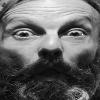

In [9]:
train_images[0]

array([[[142, 100,  78],
        [144, 102,  80],
        [148, 106,  84],
        ...,
        [238, 221, 205],
        [237, 220, 204],
        [237, 220, 204]],

       [[146, 104,  82],
        [147, 105,  83],
        [149, 107,  85],
        ...,
        [239, 222, 206],
        [238, 221, 205],
        [238, 221, 205]],

       [[150, 108,  86],
        [150, 108,  86],
        [150, 107,  88],
        ...,
        [240, 224, 208],
        [239, 223, 207],
        [239, 223, 207]],

       ...,

       [[153, 113, 121],
        [151, 111, 119],
        [149, 108, 116],
        ...,
        [236, 202, 219],
        [242, 209, 226],
        [245, 212, 229]],

       [[158, 118, 126],
        [157, 117, 125],
        [156, 115, 123],
        ...,
        [234, 200, 217],
        [239, 206, 223],
        [242, 209, 226]],

       [[159, 119, 127],
        [158, 118, 126],
        [157, 116, 124],
        ...,
        [237, 203, 220],
        [240, 207, 224],
        [243, 210, 227]]], dtype=uint8)
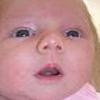

In [10]:
test_images[0]

Tạo hàm show_examples để xem các mẫu từ mỗi lớp cảm xúc

In [11]:
def show_examples(train_images, train_labels, labels, num_examples=5):
    num_classes = len(classes)
    fig, axs = plt.subplots(num_classes, num_examples, figsize=(10, 12))

    for i, class_name in enumerate(classes):
        class_indices = [idx for idx, label in enumerate(train_labels) if label == i+1]
        selected_indices = np.random.choice(class_indices, num_examples, replace=False)
        axs[i, 0].set_title(class_name, fontsize=10, pad=10, fontweight='bold')
        # Display the random images for the current class
        for j, idx in enumerate(selected_indices):
            img = train_images[idx]
            axs[i, j].imshow(img)
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()

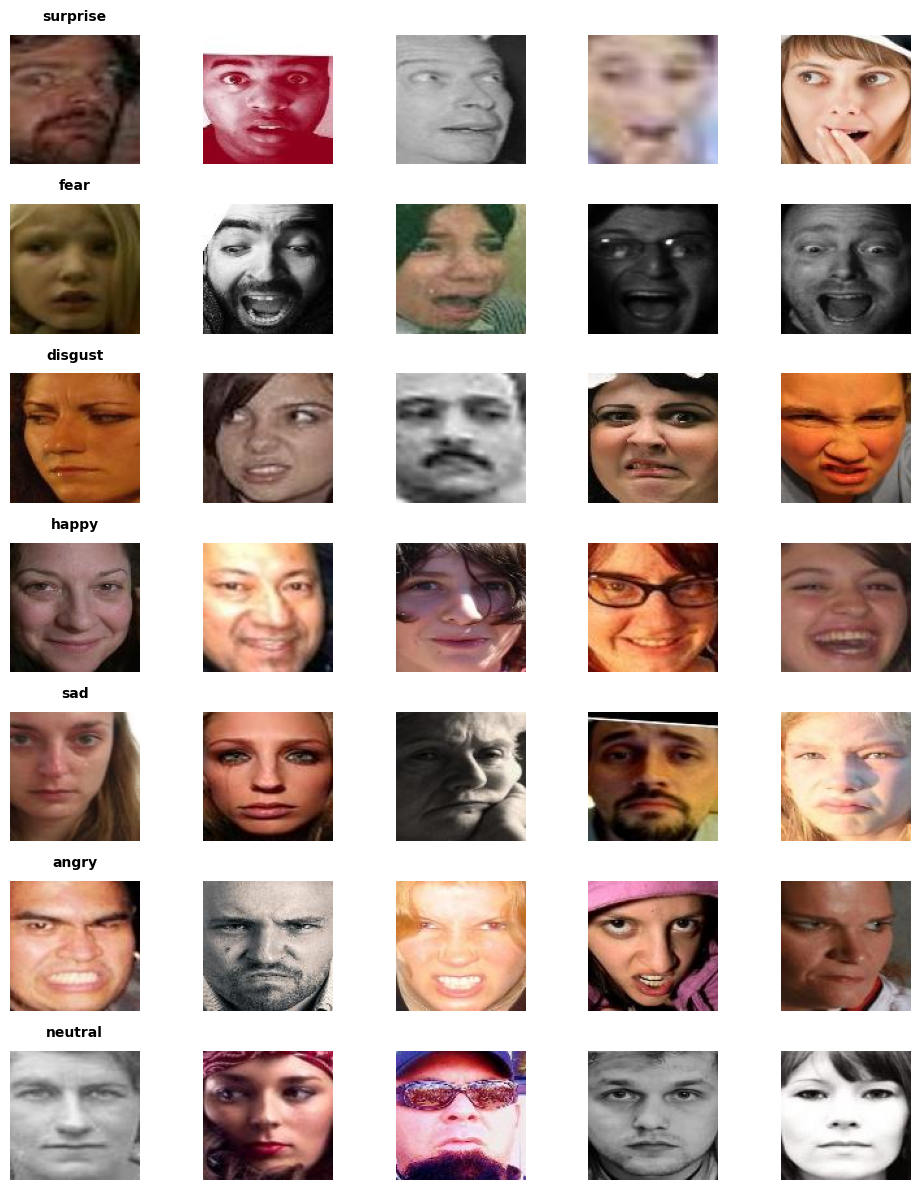

In [12]:
show_examples(train_images, train_labels, classes)

# Prepare data

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = 100   # Kích thước ảnh đầu ra mong muốn
BATCH_SIZE = 512

Chuẩn hóa giá trị pixel thành [0,1]

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
validation_datagen = ImageDataGenerator(
    rescale=1./255,
)
efficientNetB0_train_datagen = ImageDataGenerator(
    rescale=1./255,
)
efficientNetB0_validation_datagen = ImageDataGenerator(
    rescale=1./255,
)

Tạo hàm reshape ảnh , vì đầu vào EfficientNetB0 là ảnh (224x224) mà ảnh trong bộ dataset là (100x100) nên ta tiến thành reshape ảnh đầu vào cho phù hợp với kiến trúc mô hình

In [15]:
# 2. Train Generator (Tập huấn luyện)
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 3. Validation Generator (Tập kiểm tra/đánh giá)
validation_generator = validation_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
efficientNetB0_train_generator = efficientNetB0_train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
efficientNetB0_B_validation_generator = efficientNetB0_validation_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.


# Đánh giá

In [17]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
MODEL_COMPARISON_LIST = [
    {'name': 'CNN_Baseline', 'path': 'CNN_baseline.keras'},
    {'name': 'CNN_Deep', 'path': 'model_Deep.keras'},
    {'name': 'CNN_Deep2', 'path': 'CNN_Deep2.keras'},
    {'name': 'CNN_Deep3', 'path': 'CNN_Deep3.keras'},
    {'name': 'CNN_Deep3_Augmentation', 'path': 'CNN_Deep3_Augmentation.keras'},
    {'name': 'CNN_Deep3_Augmentation_Balanced', 'path': 'CNN_Deep3_Augmentation_B.keras'},
    {'name': 'EfficientNetB0_Balanced', 'path': 'efficientNetB0_B.keras'},
]

class_labels = list(validation_generator.class_indices.keys())
comparison_results = []
y_true_100x100 = validation_generator.classes
efficientNetB0_B_validation_generator.reset()
y_true_224x224 = efficientNetB0_B_validation_generator.classes

print("--- BẮT ĐẦU ĐÁNH GIÁ TỔNG THỂ CÁC MÔ HÌNH ---")
for model_info in MODEL_COMPARISON_LIST:
    name = model_info['name']
    path = model_info['path']
    print(f"\nĐánh giá: {name}...")

    # --- XÁC ĐỊNH GENERATOR CẦN DÙNG ---
    if 'EfficientNetB0' in name:
        # Sử dụng Generator 224x224 cho EfficientNet
        current_train_gen = efficientNetB0_train_generator
        current_val_gen = efficientNetB0_B_validation_generator
        current_y_true = y_true_224x224
    else:
        # Sử dụng Generator 100x100 cho CNN tùy chỉnh
        current_train_gen = train_generator
        current_val_gen = validation_generator
        current_y_true = y_true_100x100

    try:
        # 1. Load Model
        model = load_model(path)

        # 2. Đánh giá Accuracy trên TẬP TRAIN (Không dùng steps)
        current_train_gen.reset()
        _, train_acc = model.evaluate(current_train_gen, verbose=0)

        # 3. Đánh giá Accuracy trên TẬP TEST và đo thời gian (Không dùng steps)
        current_val_gen.reset()
        start_time = time.time()
        test_loss, test_acc = model.evaluate(current_val_gen, verbose=0)
        end_time = time.time()

        # 4. Dự đoán để tính Classification Report (chỉ trên tập TEST, Không dùng steps)
        current_val_gen.reset()
        predictions = model.predict(current_val_gen, verbose=0)
        y_pred = np.argmax(predictions, axis=1)

        # 5. Tính toán các chỉ số chi tiết
        # Sử dụng zero_division=0 để tránh cảnh báo khi một lớp không có mẫu nào được dự đoán/tìm thấy
        report = classification_report(current_y_true, y_pred, target_names=class_labels, output_dict=True, zero_division=0)

        # 6. Lưu kết quả
        result = {
            'Model': name,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'F1-Score (Macro Avg)': report['macro avg']['f1-score'],
            'Precision (Macro Avg)': report['macro avg']['precision'],
            'Recall (Macro Avg)': report['macro avg']['recall'],
            'Inference Time (s)': end_time - start_time
        }
        comparison_results.append(result)

    except Exception as e:
        print(f"LỖI: Không thể load hoặc đánh giá mô hình {name} từ {path}. Lỗi: {e}")

# Chuyển kết quả thành DataFrame
df_results = pd.DataFrame(comparison_results)
df_results_sorted = df_results.sort_values(by='Test Accuracy', ascending=False)

print("\n\n---------------------------------")
print("BẢNG SO SÁNH HIỆU SUẤT TỔNG THỂ")
print("---------------------------------")
print(df_results_sorted.to_markdown(index=False, floatfmt=".4f"))

# Lưu bảng so sánh vào CSV
df_results_sorted.to_csv('Model_Comparison_Table_Full.csv', index=False)

--- BẮT ĐẦU ĐÁNH GIÁ TỔNG THỂ CÁC MÔ HÌNH ---

Đánh giá: CNN_Baseline...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Đánh giá: CNN_Deep...

Đánh giá: CNN_Deep2...



Đánh giá: CNN_Deep3...



Đánh giá: CNN_Deep3_Augmentation...

Đánh giá: CNN_Deep3_Augmentation_Balanced...

Đánh giá: EfficientNetB0_Balanced...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()




---------------------------------
BẢNG SO SÁNH HIỆU SUẤT TỔNG THỂ
---------------------------------
| Model                           |   Train Accuracy |   Test Accuracy |   F1-Score (Macro Avg) |   Precision (Macro Avg) |   Recall (Macro Avg) |   Inference Time (s) |
|:--------------------------------|-----------------:|----------------:|-----------------------:|------------------------:|---------------------:|---------------------:|
| CNN_Deep3_Augmentation          |           0.8829 |          0.8194 |                 0.7267 |                  0.7750 |               0.7014 |             180.9005 |
| CNN_Deep3_Augmentation_Balanced |           0.8725 |          0.7979 |                 0.7169 |                  0.7703 |               0.6990 |             179.7088 |
| CNN_Deep3                       |           0.9245 |          0.7731 |                 0.6668 |                  0.7661 |               0.6306 |             184.7802 |
| CNN_Deep2                       |           1.

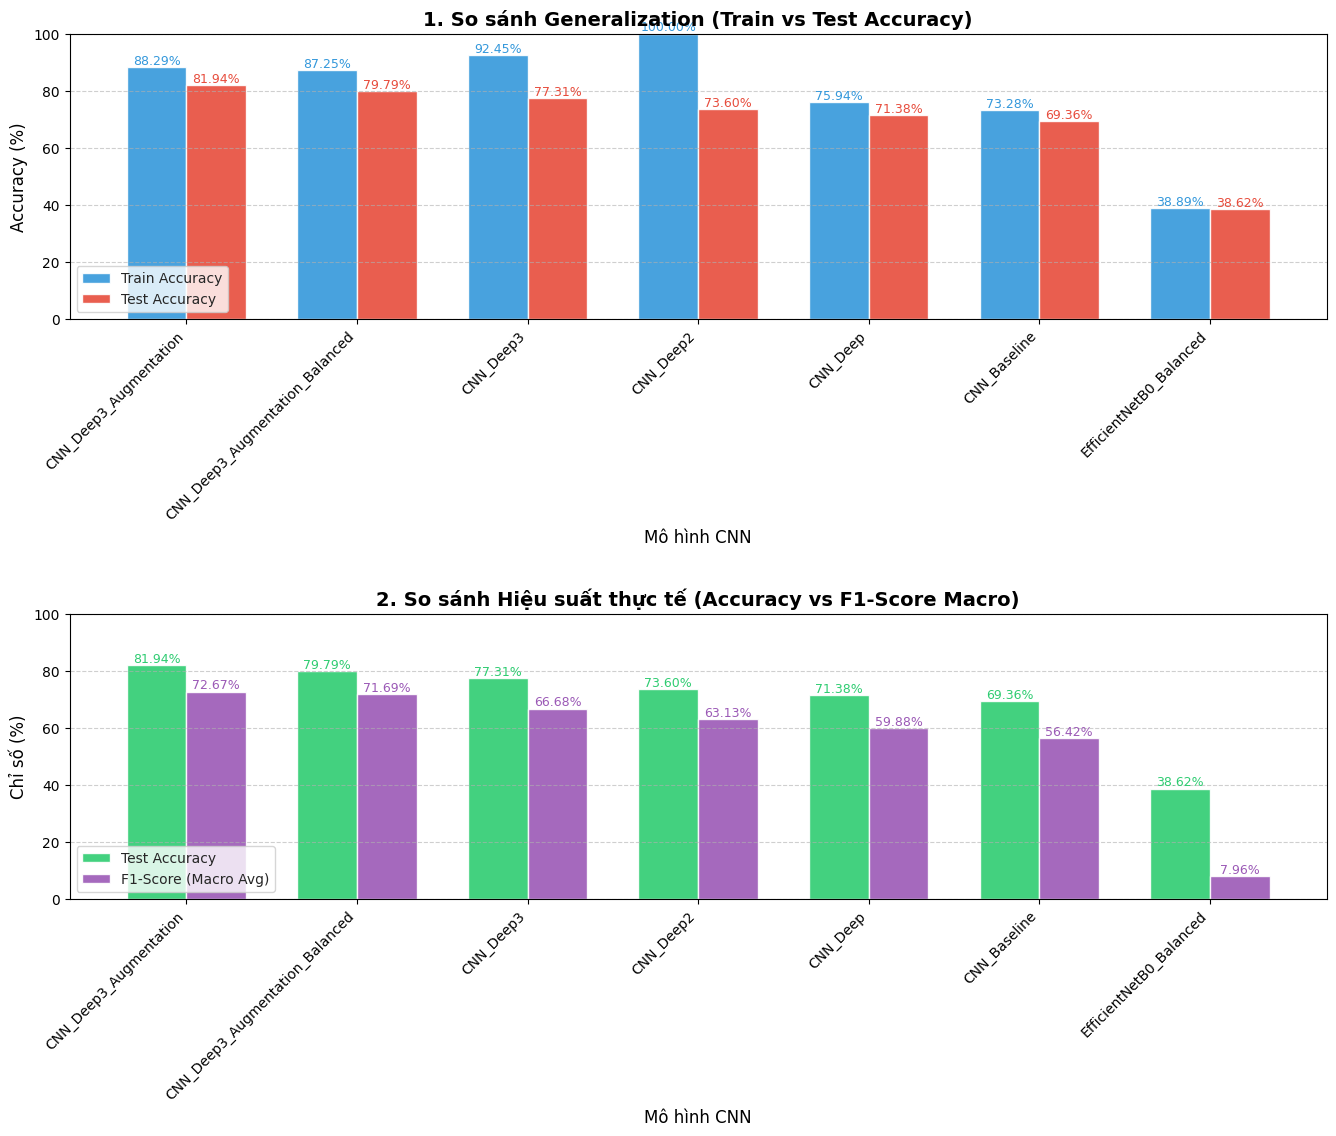


Đã tạo biểu đồ so sánh tổng hợp: Model_Combined_Comparison_Bar_Chart.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
# Giả định df_results_sorted đã có từ bước thu thập dữ liệu trước đó

# --- TẠO HAI BIỂU ĐỒ TRÊN CÙNG MỘT FIGURE (2 hàng x 1 cột) ---
df_plot = df_results_sorted.copy()
num_models = len(df_plot)
bar_width = 0.35
index = np.arange(num_models)

# Tạo figure với 2 subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
sns.set_style("whitegrid")

# --- BIỂU ĐỒ 1: SO SÁNH TRAIN ACCURACY vs TEST ACCURACY ---
ax1 = axes[0]
# Vẽ cột Train Accuracy
ax1.bar(index, df_plot['Train Accuracy'] * 100, bar_width, label='Train Accuracy', color='#3498db', alpha=0.9)
# Vẽ cột Test Accuracy (dịch vị trí sang phải)
ax1.bar(index + bar_width, df_plot['Test Accuracy'] * 100, bar_width, label='Test Accuracy', color='#e74c3c', alpha=0.9)

# Thiết lập cho ax1
ax1.set_xlabel('Mô hình CNN', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('1. So sánh Generalization (Train vs Test Accuracy)', fontsize=14, fontweight='bold')
ax1.set_xticks(index + bar_width / 2)
ax1.set_xticklabels(df_plot['Model'], rotation=45, ha='right', fontsize=10)
ax1.set_ylim([0, 100])
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị giá trị phần trăm trên đỉnh cột (ax1)
for i, acc in enumerate(df_plot['Train Accuracy']):
    ax1.text(i, acc * 100 + 1, f'{acc*100:.2f}%', ha='center', fontsize=9, color='#3498db')
for i, acc in enumerate(df_plot['Test Accuracy']):
    ax1.text(i + bar_width, acc * 100 + 1, f'{acc*100:.2f}%', ha='center', fontsize=9, color='#e74c3c')


# --- BIỂU ĐỒ 2: SO SÁNH TEST ACCURACY và F1-SCORE (Macro Avg) ---
ax2 = axes[1]
# Vẽ cột Test Accuracy
ax2.bar(index, df_plot['Test Accuracy'] * 100, bar_width, label='Test Accuracy', color='#2ecc71', alpha=0.9)
# Vẽ cột F1-Score (Macro Avg)
ax2.bar(index + bar_width, df_plot['F1-Score (Macro Avg)'] * 100, bar_width, label='F1-Score (Macro Avg)', color='#9b59b6', alpha=0.9)

# Thiết lập cho ax2
ax2.set_xlabel('Mô hình CNN', fontsize=12)
ax2.set_ylabel('Chỉ số (%)', fontsize=12)
ax2.set_title('2. So sánh Hiệu suất thực tế (Accuracy vs F1-Score Macro)', fontsize=14, fontweight='bold')
ax2.set_xticks(index + bar_width / 2)
ax2.set_xticklabels(df_plot['Model'], rotation=45, ha='right', fontsize=10)
ax2.set_ylim([0, 100])
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị giá trị phần trăm trên đỉnh cột (ax2)
for i, acc in enumerate(df_plot['Test Accuracy']):
    ax2.text(i, acc * 100 + 1, f'{acc*100:.2f}%', ha='center', fontsize=9, color='#2ecc71')
for i, f1 in enumerate(df_plot['F1-Score (Macro Avg)']):
    ax2.text(i + bar_width, f1 * 100 + 1, f'{f1*100:.2f}%', ha='center', fontsize=9, color='#9b59b6')

# Ajuster l'espacement giữa các subplot
plt.tight_layout(pad=3.0)
plt.savefig('Model_Combined_Comparison_Bar_Chart.png')
plt.show()

print("\nĐã tạo biểu đồ so sánh tổng hợp: Model_Combined_Comparison_Bar_Chart.png")

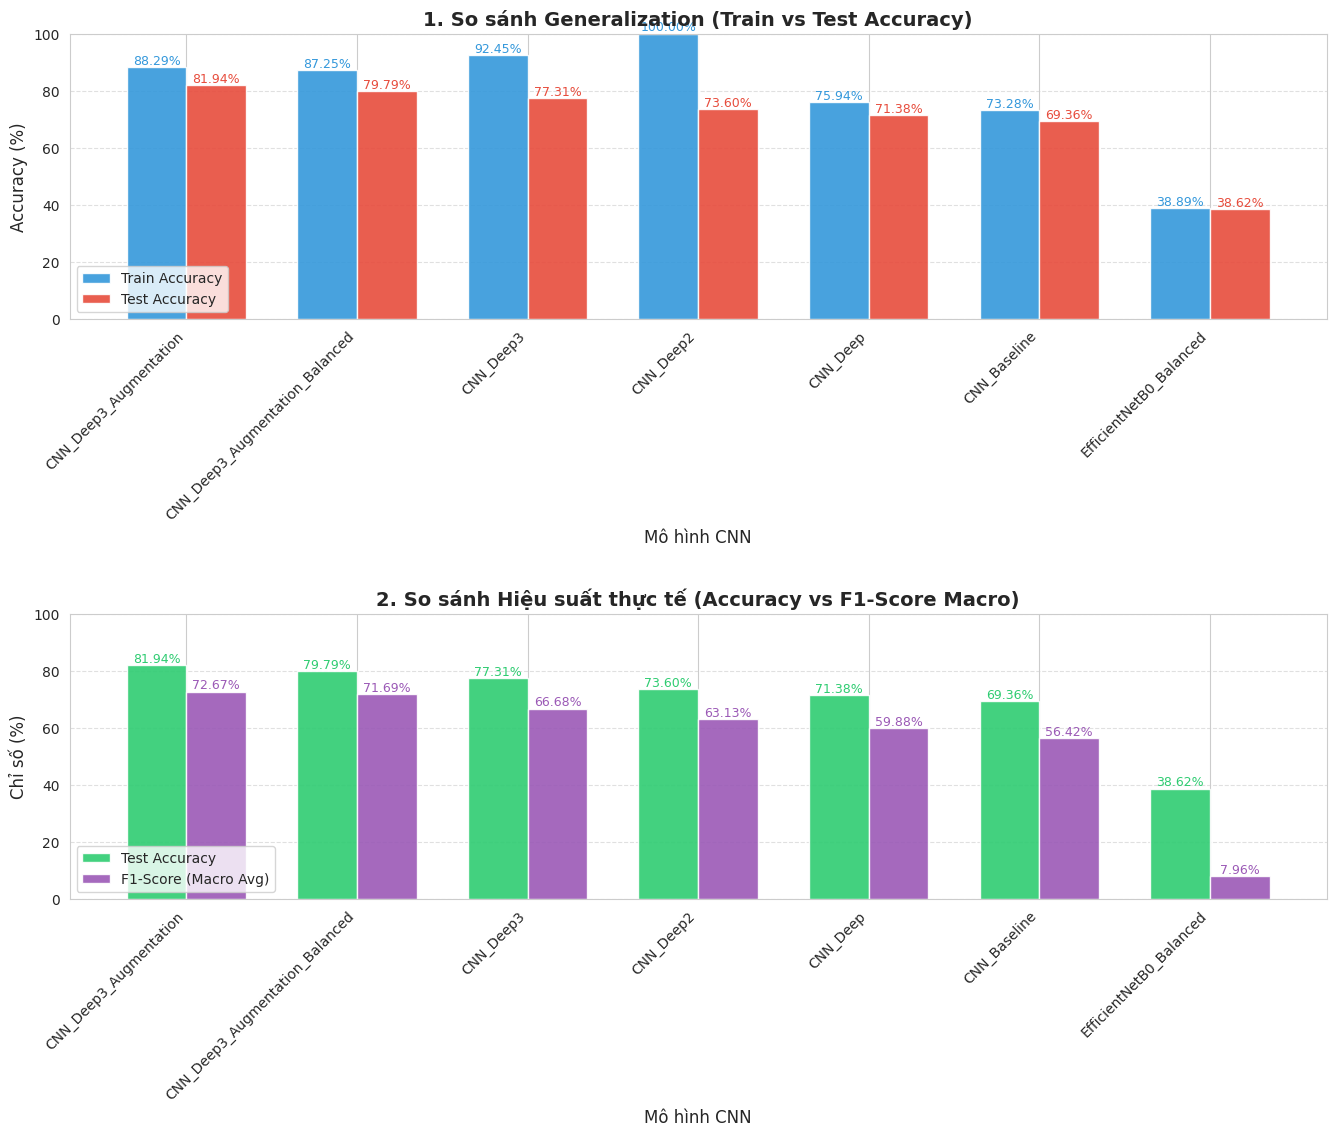

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
# --- TẠO HAI BIỂU ĐỒ TRÊN CÙNG MỘT FIGURE (2 hàng x 1 cột) ---
df_plot = df_results_sorted.copy()
num_models = len(df_plot)
bar_width = 0.35
index = np.arange(num_models)

# Tạo figure với 2 subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
sns.set_style("whitegrid")

# --- BIỂU ĐỒ 1: SO SÁNH TRAIN ACCURACY vs TEST ACCURACY ---
ax1 = axes[0]
# Vẽ cột Train Accuracy
ax1.bar(index, df_plot['Train Accuracy'] * 100, bar_width, label='Train Accuracy', color='#3498db', alpha=0.9)
# Vẽ cột Test Accuracy (dịch vị trí sang phải)
ax1.bar(index + bar_width, df_plot['Test Accuracy'] * 100, bar_width, label='Test Accuracy', color='#e74c3c', alpha=0.9)

# Thiết lập cho ax1
ax1.set_xlabel('Mô hình CNN', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('1. So sánh Generalization (Train vs Test Accuracy)', fontsize=14, fontweight='bold')
ax1.set_xticks(index + bar_width / 2)
ax1.set_xticklabels(df_plot['Model'], rotation=45, ha='right', fontsize=10)
ax1.set_ylim([0, 100])
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị giá trị phần trăm trên đỉnh cột (ax1)
for i, acc in enumerate(df_plot['Train Accuracy']):
    ax1.text(i, acc * 100 + 1, f'{acc*100:.2f}%', ha='center', fontsize=9, color='#3498db')
for i, acc in enumerate(df_plot['Test Accuracy']):
    ax1.text(i + bar_width, acc * 100 + 1, f'{acc*100:.2f}%', ha='center', fontsize=9, color='#e74c3c')


# --- BIỂU ĐỒ 2: SO SÁNH TEST ACCURACY và F1-SCORE (Macro Avg) ---
# Biểu đồ này giúp đánh giá hiệu suất thực tế trên tập Test
ax2 = axes[1]
# Vẽ cột Test Accuracy
ax2.bar(index, df_plot['Test Accuracy'] * 100, bar_width, label='Test Accuracy', color='#2ecc71', alpha=0.9)
# Vẽ cột F1-Score (Macro Avg)
ax2.bar(index + bar_width, df_plot['F1-Score (Macro Avg)'] * 100, bar_width, label='F1-Score (Macro Avg)', color='#9b59b6', alpha=0.9)

# Thiết lập cho ax2
ax2.set_xlabel('Mô hình CNN', fontsize=12)
ax2.set_ylabel('Chỉ số (%)', fontsize=12)
ax2.set_title('2. So sánh Hiệu suất thực tế (Accuracy vs F1-Score Macro)', fontsize=14, fontweight='bold')
ax2.set_xticks(index + bar_width / 2)
ax2.set_xticklabels(df_plot['Model'], rotation=45, ha='right', fontsize=10)
ax2.set_ylim([0, 100])
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị giá trị phần trăm trên đỉnh cột (ax2)
for i, acc in enumerate(df_plot['Test Accuracy']):
    ax2.text(i, acc * 100 + 1, f'{acc*100:.2f}%', ha='center', fontsize=9, color='#2ecc71')
for i, f1 in enumerate(df_plot['F1-Score (Macro Avg)']):
    ax2.text(i + bar_width, f1 * 100 + 1, f'{f1*100:.2f}%', ha='center', fontsize=9, color='#9b59b6')
# Ajuster l'espacement giữa các subplot
plt.tight_layout(pad=3.0)
plt.savefig('Model_Combined_Comparison_Bar_Chart.png')
plt.show()

# Lưu ảnh dự đoán sai (Phân tích lỗi)

In [ ]:
import shutil

ERROR_DIR = 'error'
if not os.path.exists(ERROR_DIR):
    # os.makedirs tạo thư mục và mọi thư mục cha cần thiết
    os.makedirs(ERROR_DIR)
    print(f"Thư mục '{ERROR_DIR}' đã được tạo.")
# Đảo ngược mapping để lấy tên nhãn từ index (ví dụ: 0 -> angry)
idx_to_label = {v: k for k, v in validation_generator.class_indices.items()}
errors_idx = np.where(y_true != y_pred)[0]
# Lưu các mẫu sai
for i, idx in enumerate(errors_idx):
    filepath = validation_generator.filepaths[idx]
    true_label_idx = y_true[idx]
    pred_label_idx = y_pred[idx]

    true_label = idx_to_label.get(true_label_idx, str(true_label_idx))
    pred_label = idx_to_label.get(pred_label_idx, str(pred_label_idx))

    # Copy ảnh vào folder error
    filename = os.path.basename(filepath)
    new_filename = f"True_{true_label}_Pred_{pred_label}_{filename}"

    try:
        shutil.copy(filepath, os.path.join(ERROR_DIR, new_filename))
    except FileNotFoundError:
        # Xử lý trường hợp không tìm thấy file, có thể do môi trường khác nhau
        pass

print(f"Đã lưu các mẫu sai vào thư mục '{ERROR_DIR}'.")
print("Vui lòng kiểm tra thư mục này trên hệ thống của bạn.")

In [ ]:
# !zip -r /content/error.zip /content/error